In [19]:
import json
import pandas as pd

fin = open("data.json", "r")
s = fin.read()
fin.close()

data = json.loads(s)



In [20]:
names = []
dos =   []
year =  []
price = []
mileage = []
fuel = []
transmission = []
body = []
sale_loc = []
description = []
brand_list = []

for brand in data.keys():
    for car in data[brand]:
        names.append(car.get("name"))
        dos.append(car.get("Date of Sale"))
        brand_list.append(brand)
        year.append(car.get("Year"))
        price.append(car.get("Sale Price"))
        mileage.append(car.get("Mileage"))
        fuel.append(car.get("Fuel Type"))
        transmission.append(car.get("Transmission"))
        body.append(car.get("Body Type"))
        sale_loc.append(car.get("Sale Location"))
        description.append(car.get("Description"))
        
        
d = {"Name": names, "Date of Sale": dos, "Year": year, 
     "Price": price, "Mileage": mileage, "Fuel Type": fuel, 
     "Transmission Type": transmission, "Body": body, "Sale Location": sale_loc, "Description": description, "Brand": brand_list}
        


df = pd.DataFrame(d)
df




,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand
0,BMW 1 Series (116d),2025-01-02,2019,"€ 9,445.00","66,239 km",diesel,Automatic,Hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW
1,BMW 3 Series (SE Business Edition),02/01/2025,2012,"€ 6,495.00","166,517",Diesel,automatic,Estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW
2,BMW X1 (SE),2025-01-03,2019,"€15,429.00","70,121",Diesel,Manual,SUV,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW
3,BMW 8 Series (840d),05/01/2025,2022,"€ 58,023.00","16,906 km",Diesel,Automatic,Convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,€20962.00,"54,026",petrol,automatic,Hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW
...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,"€23,379.00",17892,Petrol,manual,SUV,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen
1650,Volkswagen Polo (Moda),18/12/2025,2012,"€ 3,802","178,967",Petrol,Manual,Hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen
1651,Volkswagen Polo (SE),18/12/2025,2018,"9,743","61,509",Petrol,Manual,Hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen
1652,Volkswagen Polo (GTI),21/12/2025,2018,€ 15288.00,"31,171",petrol,Manual,Hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen


In [21]:
# print(df["Date of Sale"])
df["Date of Sale"] = df["Date of Sale"].astype(str).str.strip()

month_names = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# Rewrite all dates in DD-MM-YYYY format
df["Date of Sale"] = pd.to_datetime(df["Date of Sale"], errors='raise', dayfirst=True, format="mixed")
# Remove leading whitespace from all years

# Remove EUR or € from all prices, and remove whitespace and commas
df["Price"] = df["Price"].astype(str).str.replace(",", "")
df["Price"] = df["Price"].astype(str).str.replace(" ", "")
df["Price"] = df["Price"].astype(str).str.replace("EUR", "")
df["Price"] = df["Price"].astype(str).str.replace("€", "")

# Remove whitespace, km and kms from mileage
df["Mileage"] = df["Mileage"].astype(str)
df["Mileage"] = df["Mileage"].str.replace(",", "", regex=False).str.replace(" ", "", regex=False).str.replace("kms", "", regex=False).str.replace("km", "", regex=False)


# Clearn up transmission type
df["Transmission Type"] = df["Transmission Type"].astype(str).str.lower()
df["Transmission Type"] = df["Transmission Type"].str.replace(" ", "", regex=False).replace({"auto": "automatic"})



df["Fuel Type"] = df["Fuel Type"].astype(str).str.lower()
df["Fuel Type"] = df["Fuel Type"].astype(str).str.replace(" ", "")

# If it contains "diesel" and "hybrid", change to "diesel-hybrid"
df["Fuel Type"].loc[df["Fuel Type"].str.contains("diesel") & df["Fuel Type"].str.contains("hybrid")] = "diesel-hybrid"
df["Fuel Type"].loc[df["Fuel Type"].str.contains("petrol") & df["Fuel Type"].str.contains("hybrid")] = "petrol-hybrid"

# Store Mileage and Price as floats
df["Price"] = df["Price"].astype(float)
df["Mileage"] = df["Mileage"].astype(float)

# Store year as ints
df["Year"] = df["Year"].astype(int)
# Clean up County Names

df["Sale Location"] =  df["Sale Location"].str.strip()

# Some descriptions contain colour and some have number of previous owners. Add these to the dataset
colours = ["grey", "red", "black", "blue", "silver", "white", "green"]
for colour in colours:
    mask = df["Description"].astype(str).str.lower().str.contains(colour, na=False)
    df.loc[mask, "Colour"] = colour

def extract_number_of_owners(description):
    split_desc = description.split(" ")
    if "previous" in split_desc:
        previous_index = split_desc.index("previous")
        return(split_desc[previous_index -1])
    else:
        return None


df["Previous Owners"] = df["Description"].apply(extract_number_of_owners)


#print any missing values
print(df.isnull().sum())

df


Name                   0
Date of Sale           0
Year                   0
Price                  0
Mileage                0
Fuel Type              0
Transmission Type      0
Body                   0
Sale Location          0
Description            0
Brand                  0
Colour               210
Previous Owners      686
dtype: int64


/tmp/ipykernel_37718/932133239.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fuel Type"].loc[df["Fuel Type"].str.contains("diesel") & df["Fuel Type"].str.contains("hybrid")] = "diesel-hybrid"
/tmp/ipykernel_37718/932133239.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fuel Type"].loc[df["Fuel Type"].str.contains("petrol") & df["Fuel Type"].str.contains("hybrid")] = "petrol-hybrid"


,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand,Colour,Previous Owners
0,BMW 1 Series (116d),2025-01-02,2019,9445.0,66239.0,diesel,automatic,Hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW,grey,3
1,BMW 3 Series (SE Business Edition),2025-01-02,2012,6495.0,166517.0,diesel,automatic,Estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW,silver,2
2,BMW X1 (SE),2025-01-03,2019,15429.0,70121.0,diesel,manual,SUV,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW,NaN,None
3,BMW 8 Series (840d),2025-01-05,2022,58023.0,16906.0,diesel,automatic,Convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW,black,2
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,20962.0,54026.0,petrol,automatic,Hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW,blue,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,23379.0,17892.0,petrol,manual,SUV,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen,green,1
1650,Volkswagen Polo (Moda),2025-12-18,2012,3802.0,178967.0,petrol,manual,Hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen,NaN,4
1651,Volkswagen Polo (SE),2025-12-18,2018,9743.0,61509.0,petrol,manual,Hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen,white,2
1652,Volkswagen Polo (GTI),2025-12-21,2018,15288.0,31171.0,petrol,manual,Hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen,blue,2


In [22]:
# Check for missing values
df["Body"].value_counts()

Body
Hatchback      469
SUV            384
Saloon         368
Coupe          167
Estate         136
Convertible    104
S.U.V.          20
Estat            6
Name: count, dtype: int64

In [23]:
df["Sale Location"].value_counts()

Sale Location
Dublin       486
Cork         185
Galway        97
Kildare       83
Meath         79
Limerick      64
Donegal       61
Louth         58
Waterford     56
Wexford       54
Tipperary     45
Kerry         43
Mayo          40
Wicklow       37
Cavan         29
Offaly        27
Roscommon     27
Westmeath     25
Kilkenny      24
Clare         24
Laois         23
Sligo         22
Monaghan      20
Carlow        20
Leitrim       15
Longford      10
Name: count, dtype: int64

<Axes: >

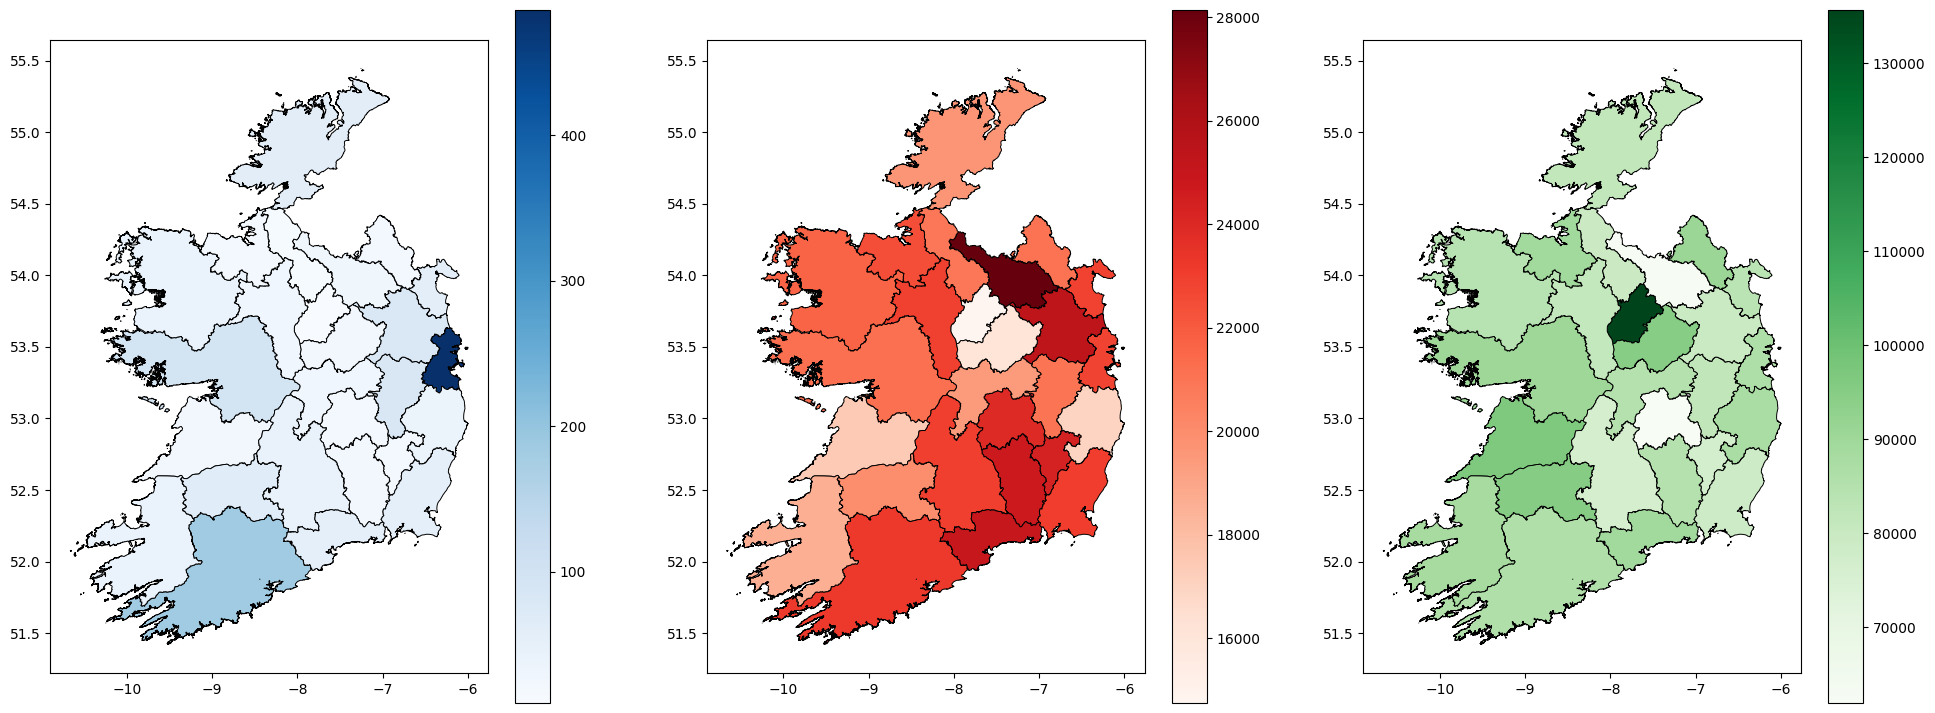

In [24]:
# Maps of Ireland Redone
import geopandas as gpd
import matplotlib.pyplot as plt

# Read GeoJSON file
ireland = gpd.read_file("ireland-counties.geojson")

# Have to map undefined regions (i.e., Limerick City to Limerick) and remove "County" from everything
name_map = {
    "Limerick City": "Limerick",
    "Limerick County": "Limerick",
    "North Tipperary": "Tipperary",
    "South Tipperary": "Tipperary",
    "Waterford City": "Waterford",
    "Waterford County": "Waterford",
    "Galway City": "Galway",
    "Galway County": "Galway",
    "Dublin City": "Dublin",
    "South Dublin": "Dublin",
    "Fingal": "Dublin",
    "Dún Laoghaire-Rathdown": "Dublin",
    "Cork City": "Cork",
    "Cork County": "Cork",
}

def map_to_pandas_county_format(geopandas_name):
    county = name_map.get(geopandas_name, None)
    if county == None:
        return geopandas_name.replace("County", "").strip()
    return county
    
    
ireland["Sale Location"] = ireland["name"].map(map_to_pandas_county_format)
ireland = ireland.dissolve(by="Sale Location").reset_index() # To merge counties together

# Make a dataframe of just the average mileage and price per county so it can be merged with ireland
# Also include the number of cars sold in each region
avg_prices = df.groupby("Sale Location")["Price"].mean()
avg_mileage = df.groupby("Sale Location")["Mileage"].mean()
count = df["Sale Location"].value_counts()

# Merge the Dataframes
ireland = ireland.merge(avg_prices, on="Sale Location", how="inner")
ireland = ireland.merge(avg_mileage, on="Sale Location", how="inner")
ireland = ireland.merge(count, on="Sale Location", how="inner")

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

ireland.plot(
    column="count",
    ax=axes[0],
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )

ireland.plot(
    column="Price",
    ax=axes[1],
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )


ireland.plot(
    column="Mileage",
    ax=axes[2],
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )


<Axes: xlabel='Year'>

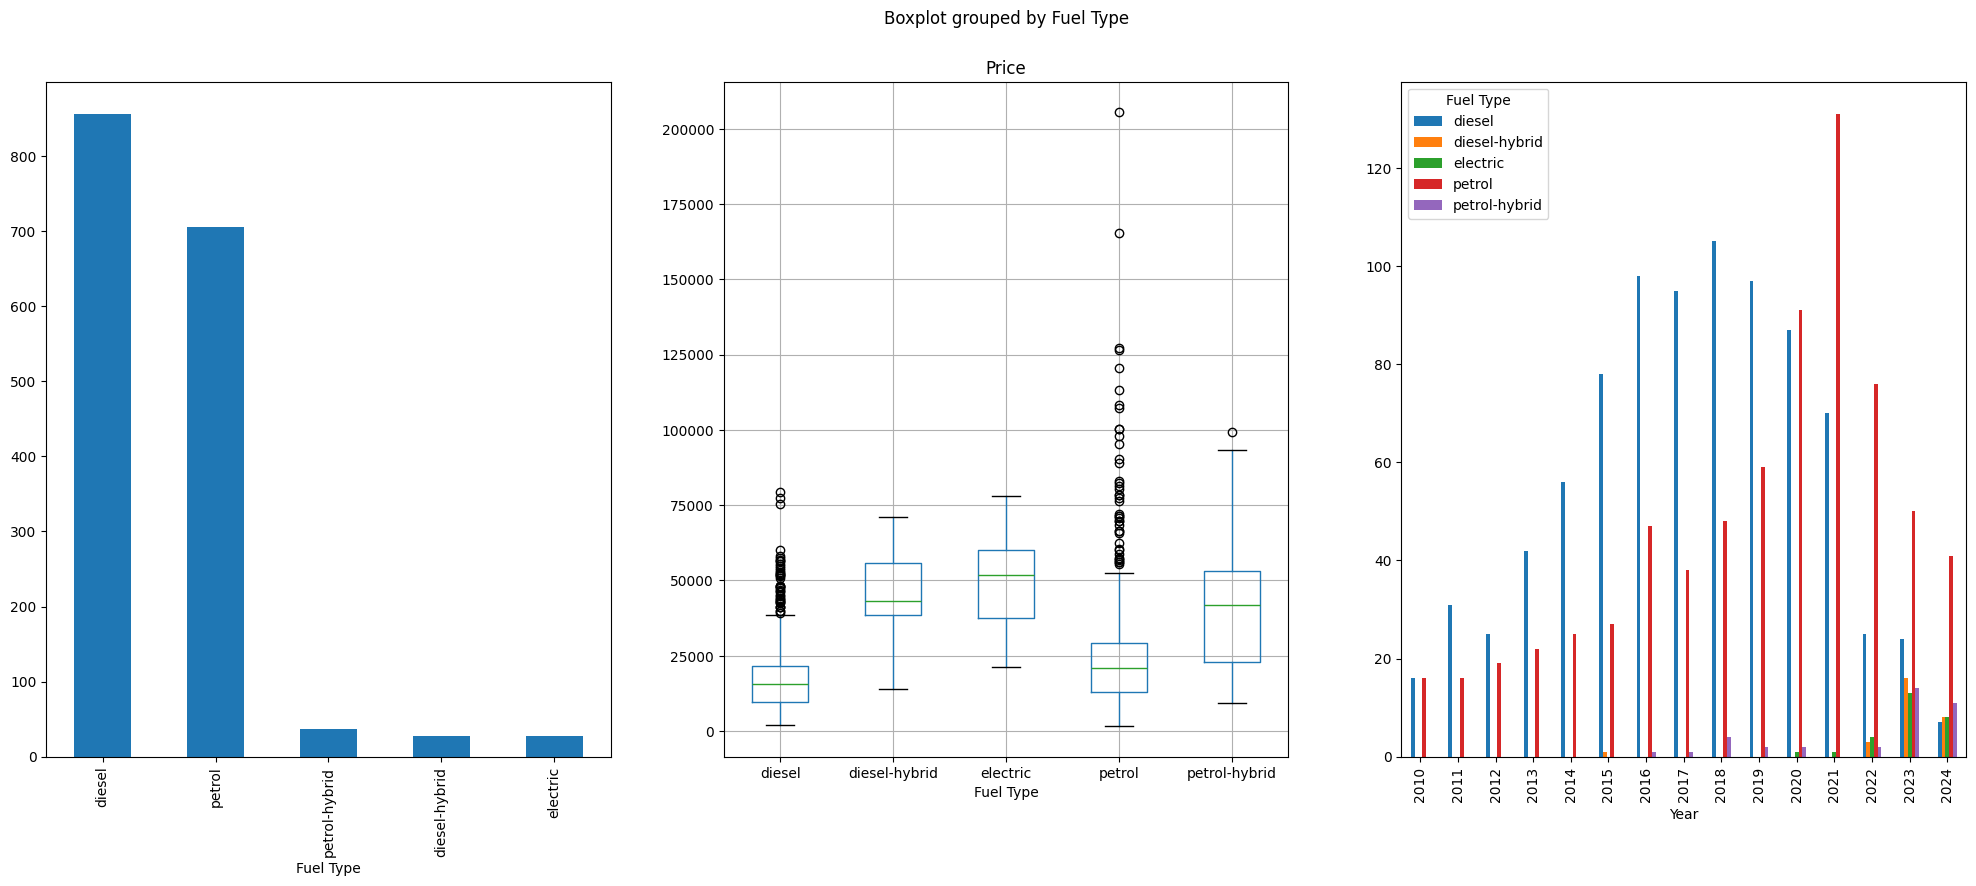

In [25]:
# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

# Plot the total number of each Fuel type sold
df["Fuel Type"].value_counts().plot(kind="bar", ax = axes[0])

# Compare the price of different fuel types
df.boxplot(column="Price",
           by="Fuel Type",
           ax = axes[1])

# Compare the number of each fuel type sold per year
# Using unstack here changes it from a dataframe with year, fuel type and count as the columns to 
# one with year, diesel, petrol etc. as the columns with the counts as the entries
df.groupby("Year")["Fuel Type"].value_counts().unstack().plot(kind="bar", ax= axes[2])


<Axes: xlabel='Year'>

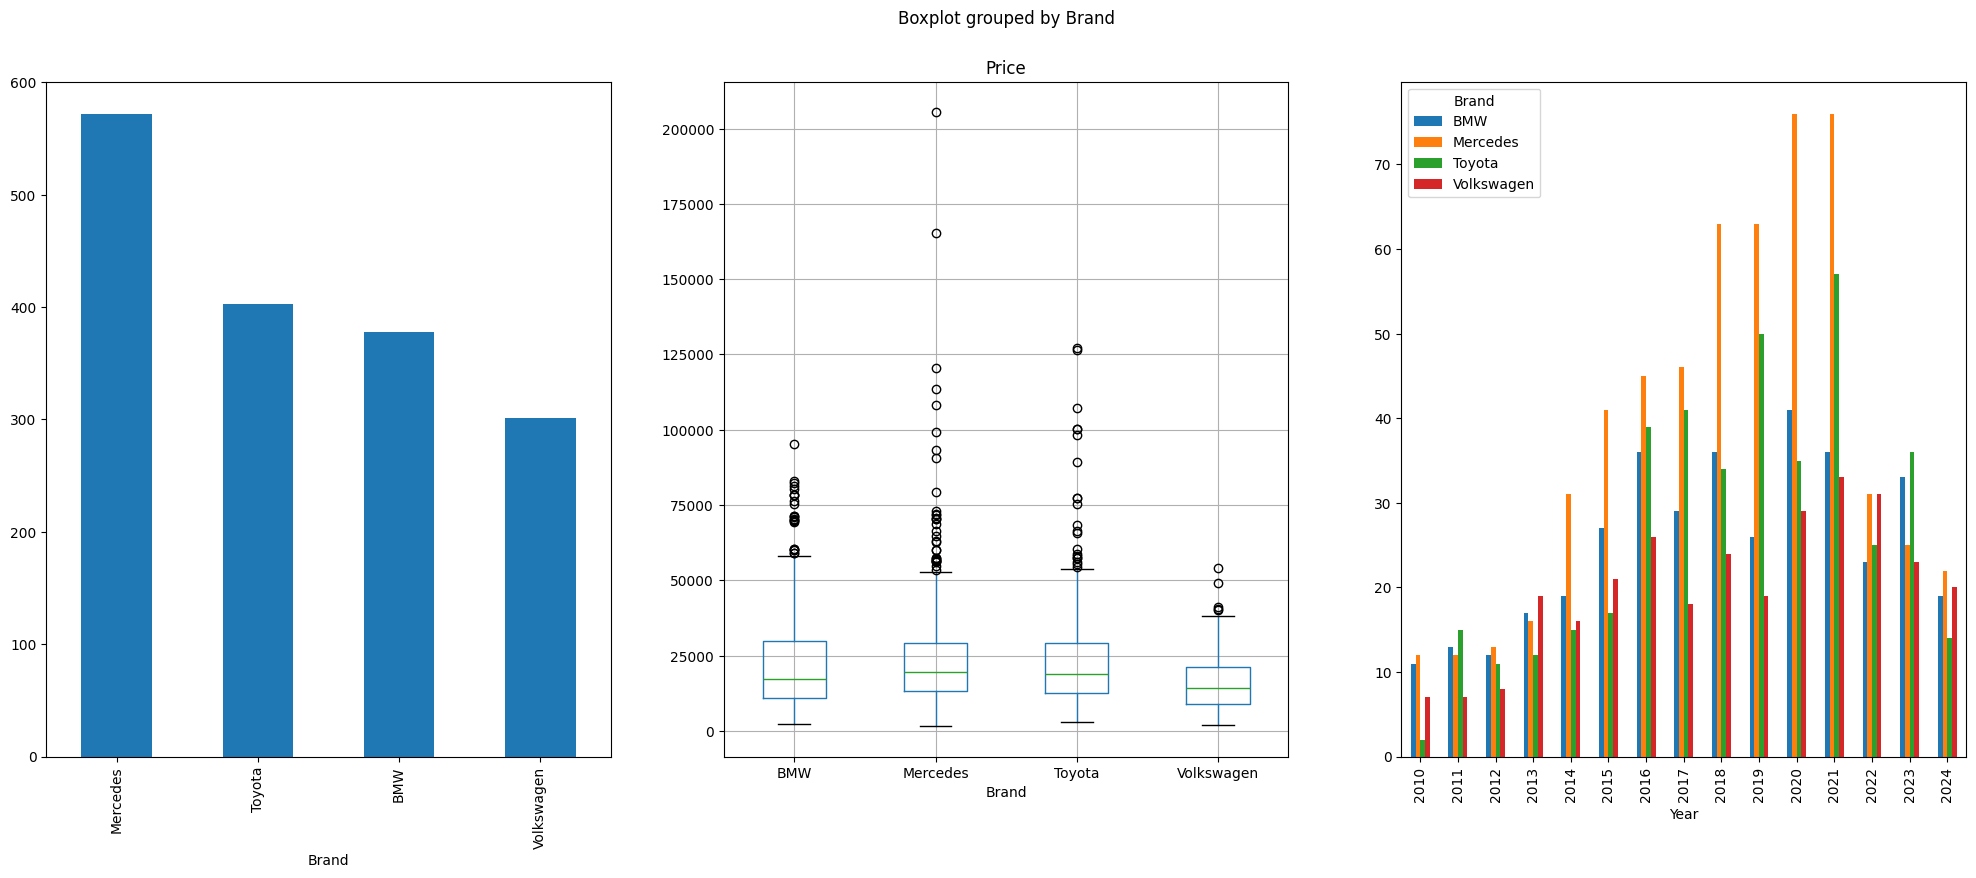

In [26]:
# Brand analysis
# three plots. 1. number of each car brand sold, 2. Price of each brand, 3. Avg. age per brand

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

df["Brand"].value_counts().plot(kind="bar", ax = axes[0]) #TODO verify that this is correct off the number of pages on website

df.boxplot(column="Price",
           by="Brand",
           ax = axes[1])

df.groupby("Year")["Brand"].value_counts().unstack().plot(kind="bar", ax= axes[2])


<Axes: xlabel='Year'>

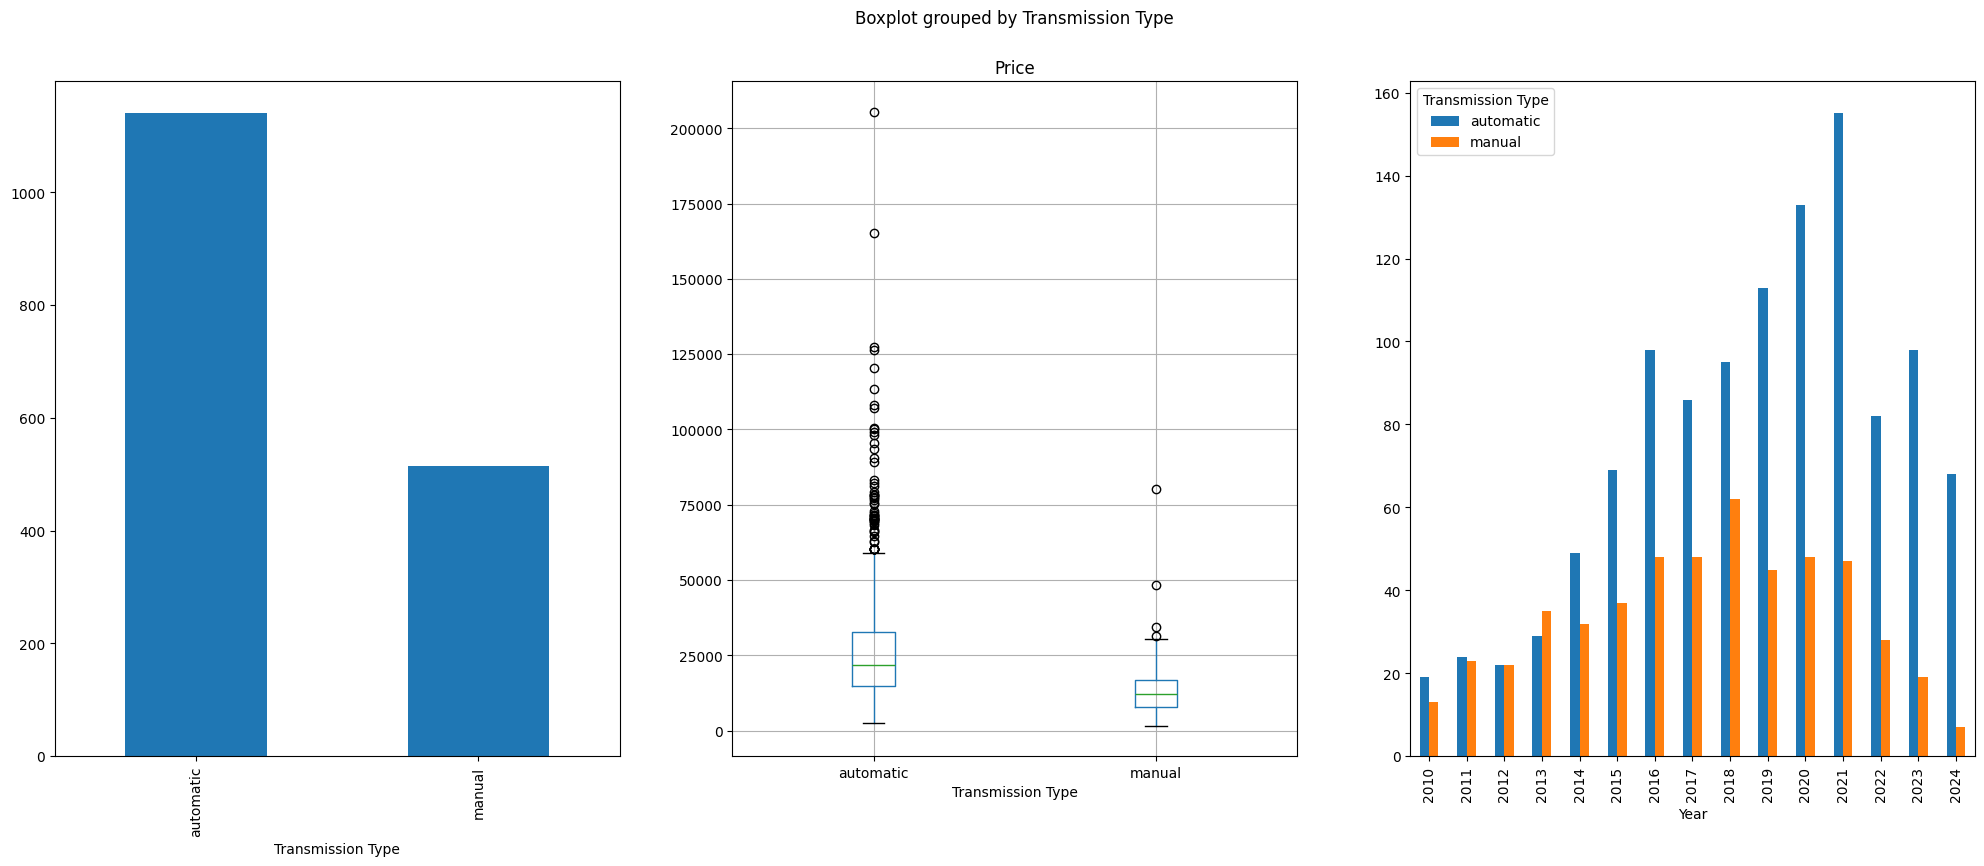

In [27]:
# Do the same for transmission type

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

df["Transmission Type"].value_counts().plot(kind="bar", ax = axes[0]) #TODO verify that this is correct off the number of pages on website

df.boxplot(column="Price",
           by="Transmission Type",
           ax = axes[1])

df.groupby("Year")["Transmission Type"].value_counts().unstack().plot(kind="bar", ax= axes[2])

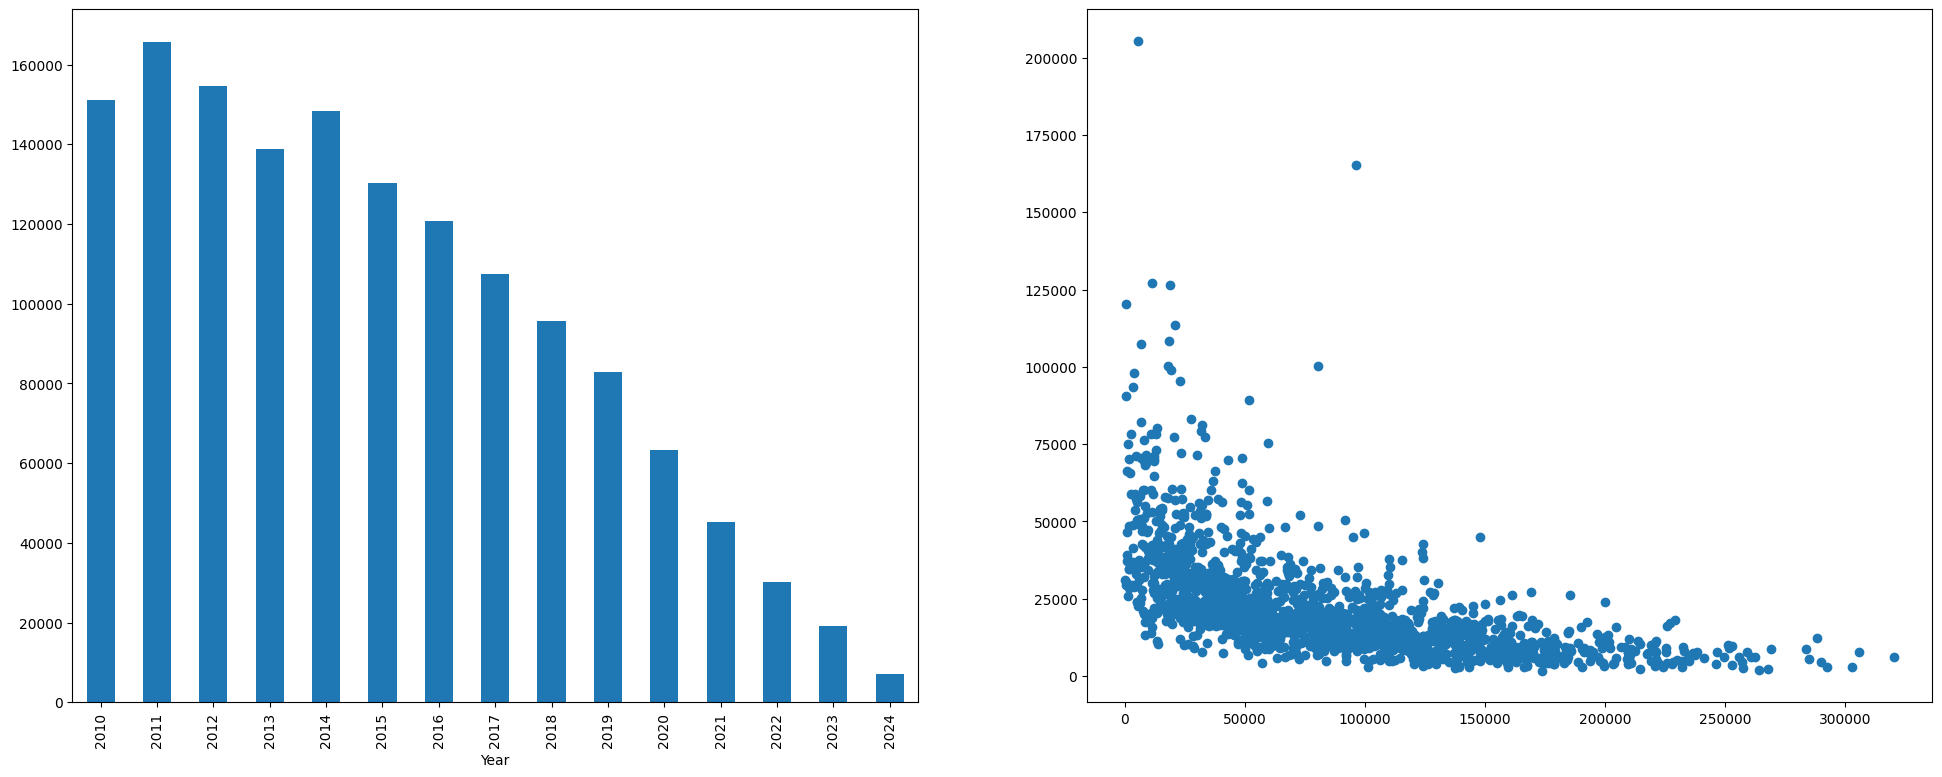

In [28]:
# Mileage plots
# 1. Mileage vs Year. #2. Mileage vs Price

# One figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

df.groupby("Year")["Mileage"].mean().plot(kind="bar", ax=axes[0])

# Mileage vs price scatter plot
plt.scatter(df["Mileage"], df["Price"])


<Axes: title={'center': 'Price'}, xlabel='Year'>

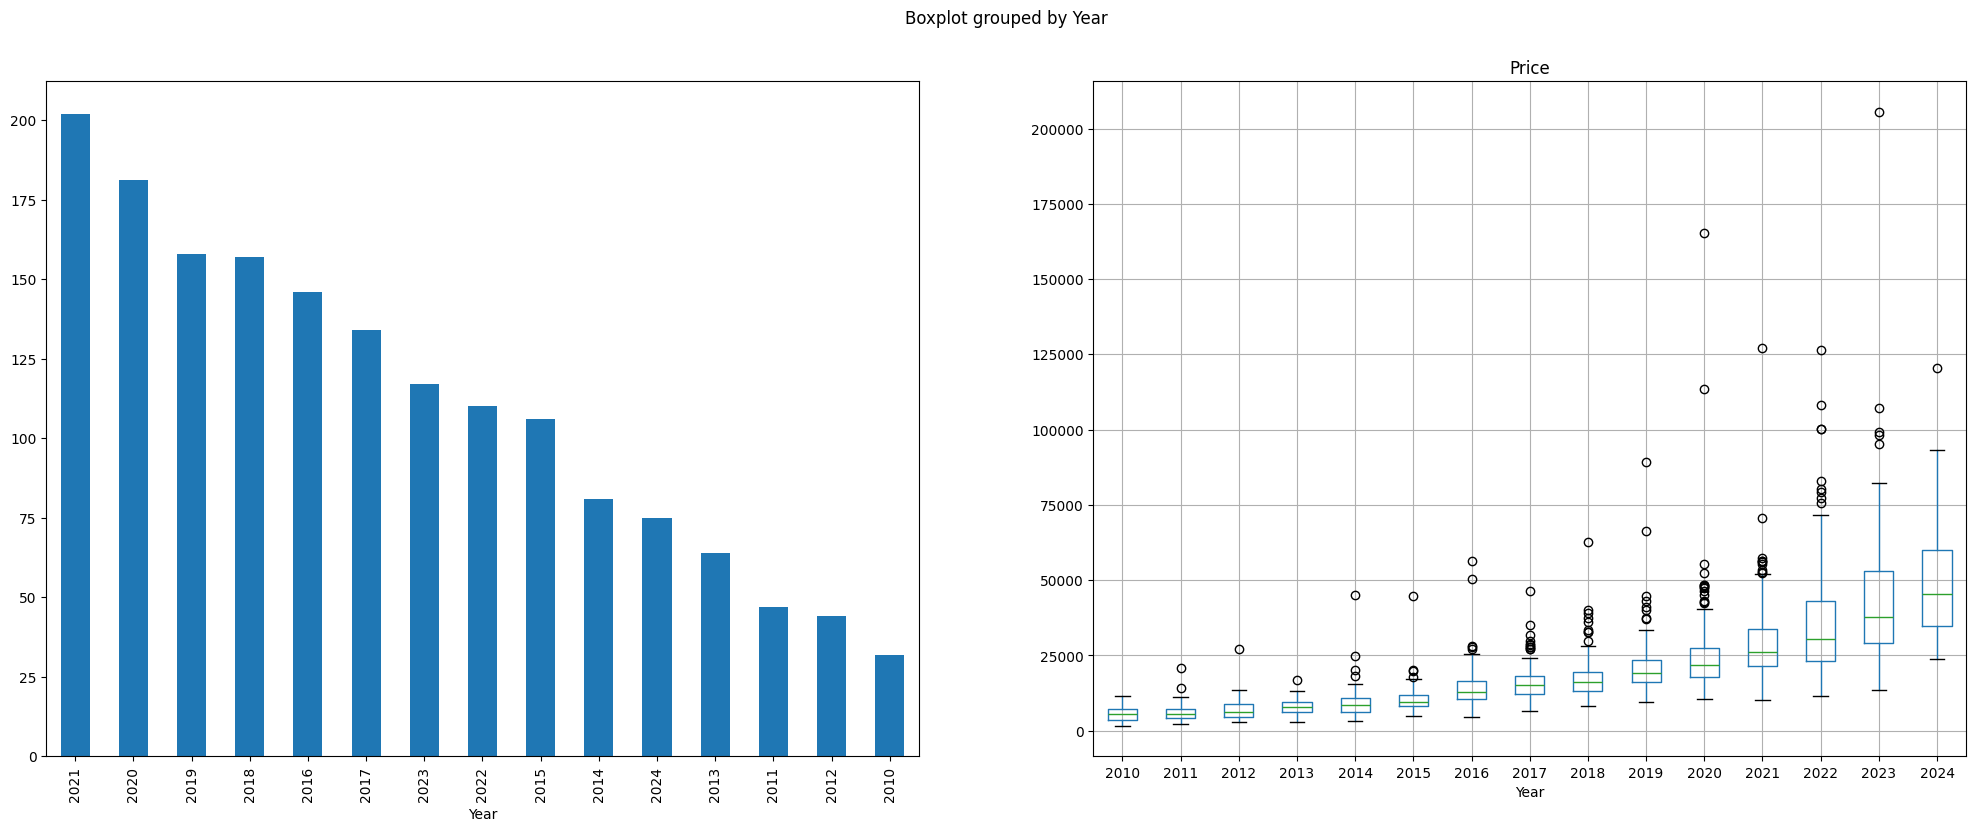

In [29]:
# Prices plots
# 1. Distribution of how old cars are, # 2. Price distribution by year
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

df["Year"].value_counts().plot(kind="bar", ax=axes[0])

# Year vs price box plot
df.boxplot(column="Price", by="Year", ax=axes[1])


<Axes: xlabel='Date of Sale'>

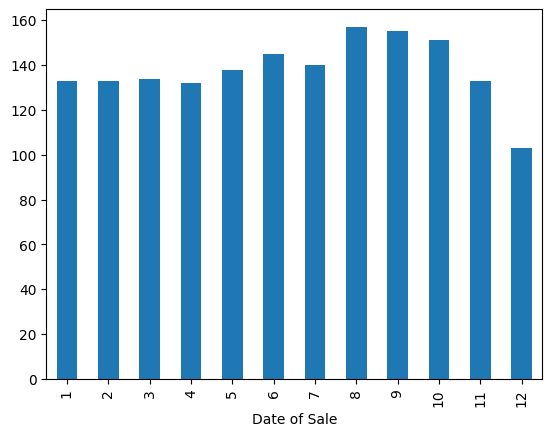

In [30]:
# Are car sales seasonal?
month_counts = df["Date of Sale"].dt.month.value_counts().sort_index()
month_counts.plot(kind="bar")

<Axes: title={'center': 'Price'}, xlabel='Has Big City'>

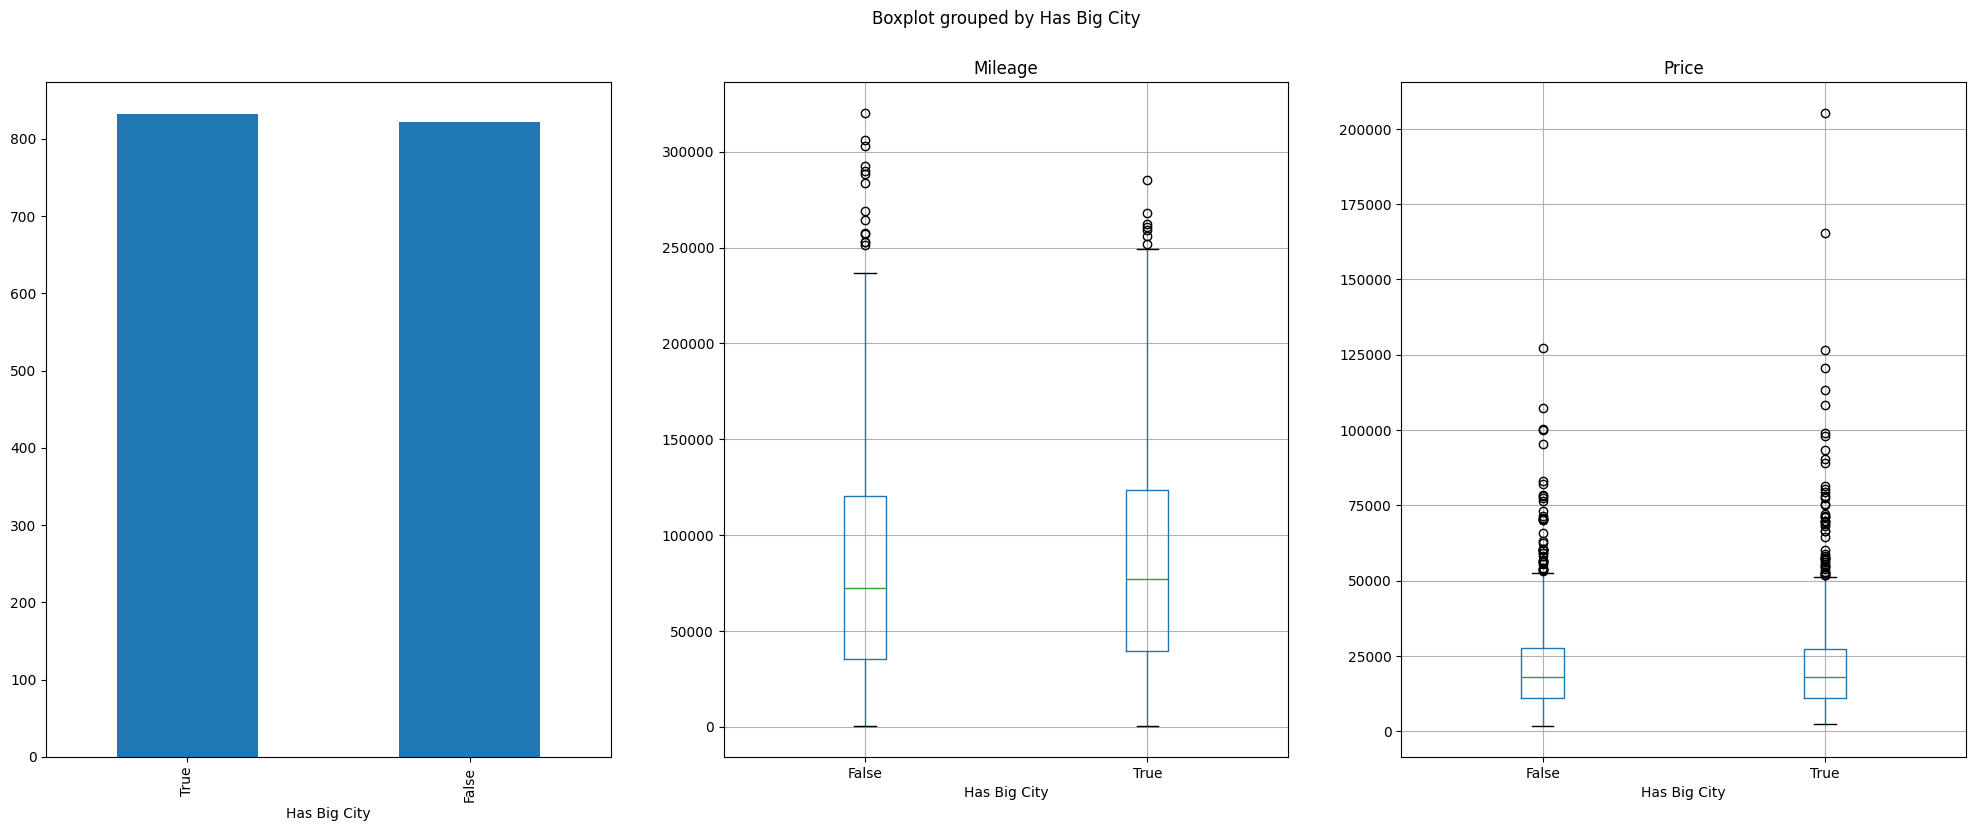

In [31]:
# Compare the mileage in counties with and without big cities
# One figure with 2 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

counties_with_big_cities = ["Dublin", "Limerick", "Cork", "Galway"]

df["Has Big City"] = df["Sale Location"].isin(counties_with_big_cities)

# Compare the number of cars sold with and without big cities
df["Has Big City"].value_counts().plot(kind="bar", ax=axes[0])

df.boxplot(column="Mileage", by="Has Big City", ax=axes[1])

# Compare prices in counties with and without big city
df.boxplot(column="Price", by="Has Big City", ax=axes[2])



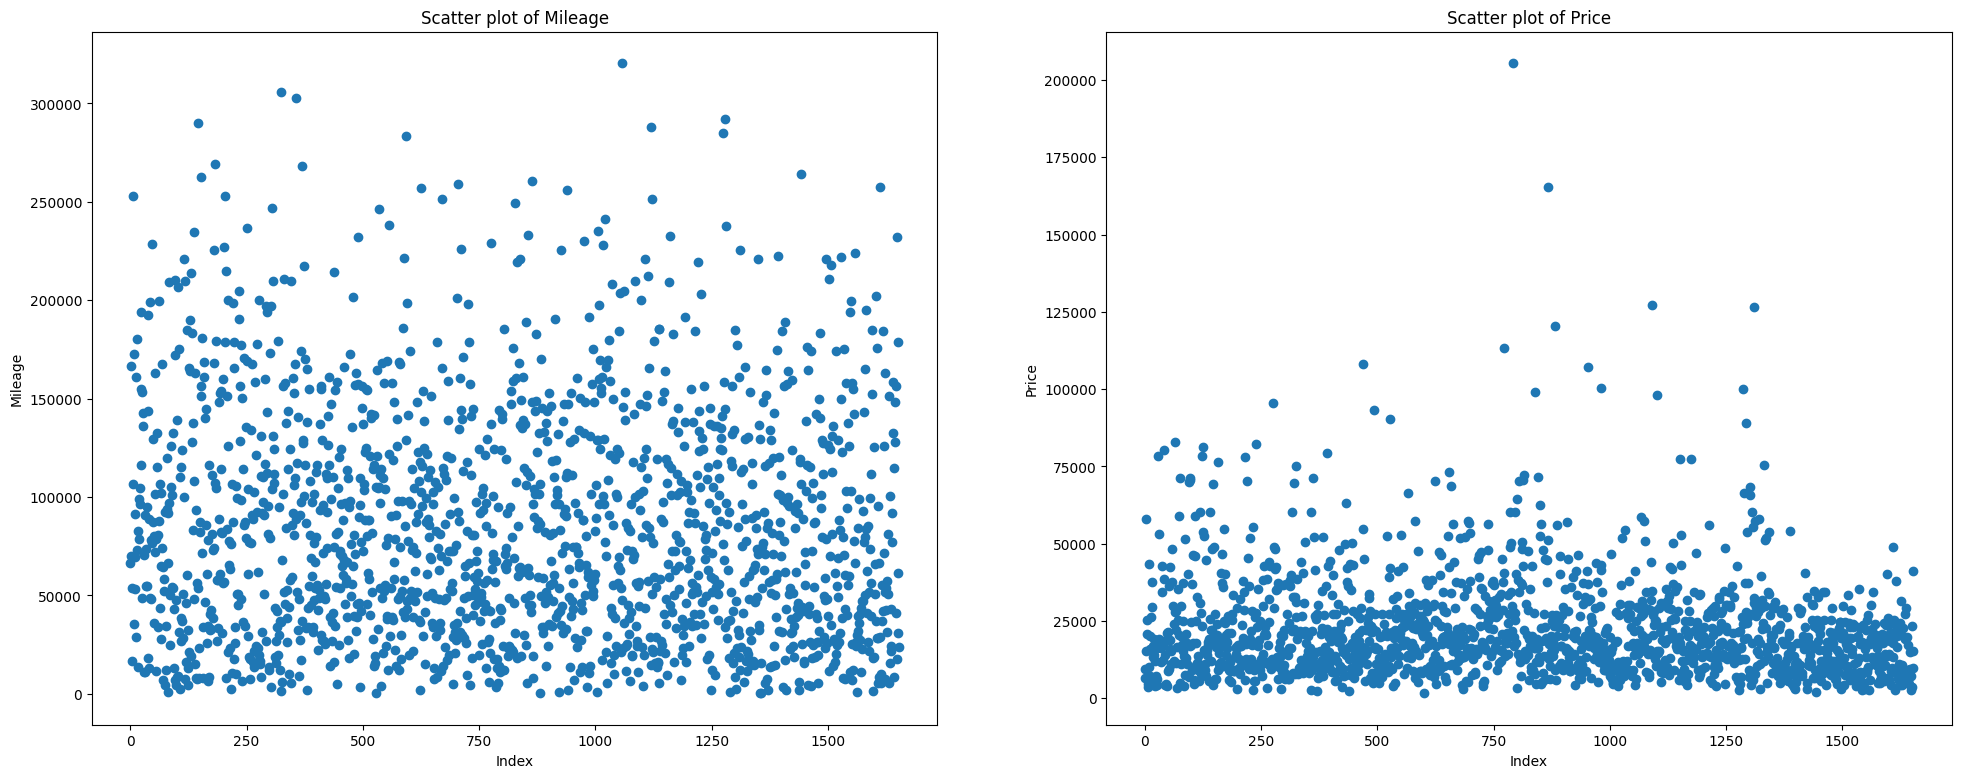

In [32]:
# Find any statistical outliers in the price and mileage data
# TODO make these boxplots maybe

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

axes[0].scatter(df.index, df["Mileage"])
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Mileage")
axes[0].set_title("Scatter plot of Mileage")

axes[1].scatter(df.index, df["Price"])
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Price")
axes[1].set_title("Scatter plot of Price")

plt.show()


<Axes: xlabel='Previous Owners'>

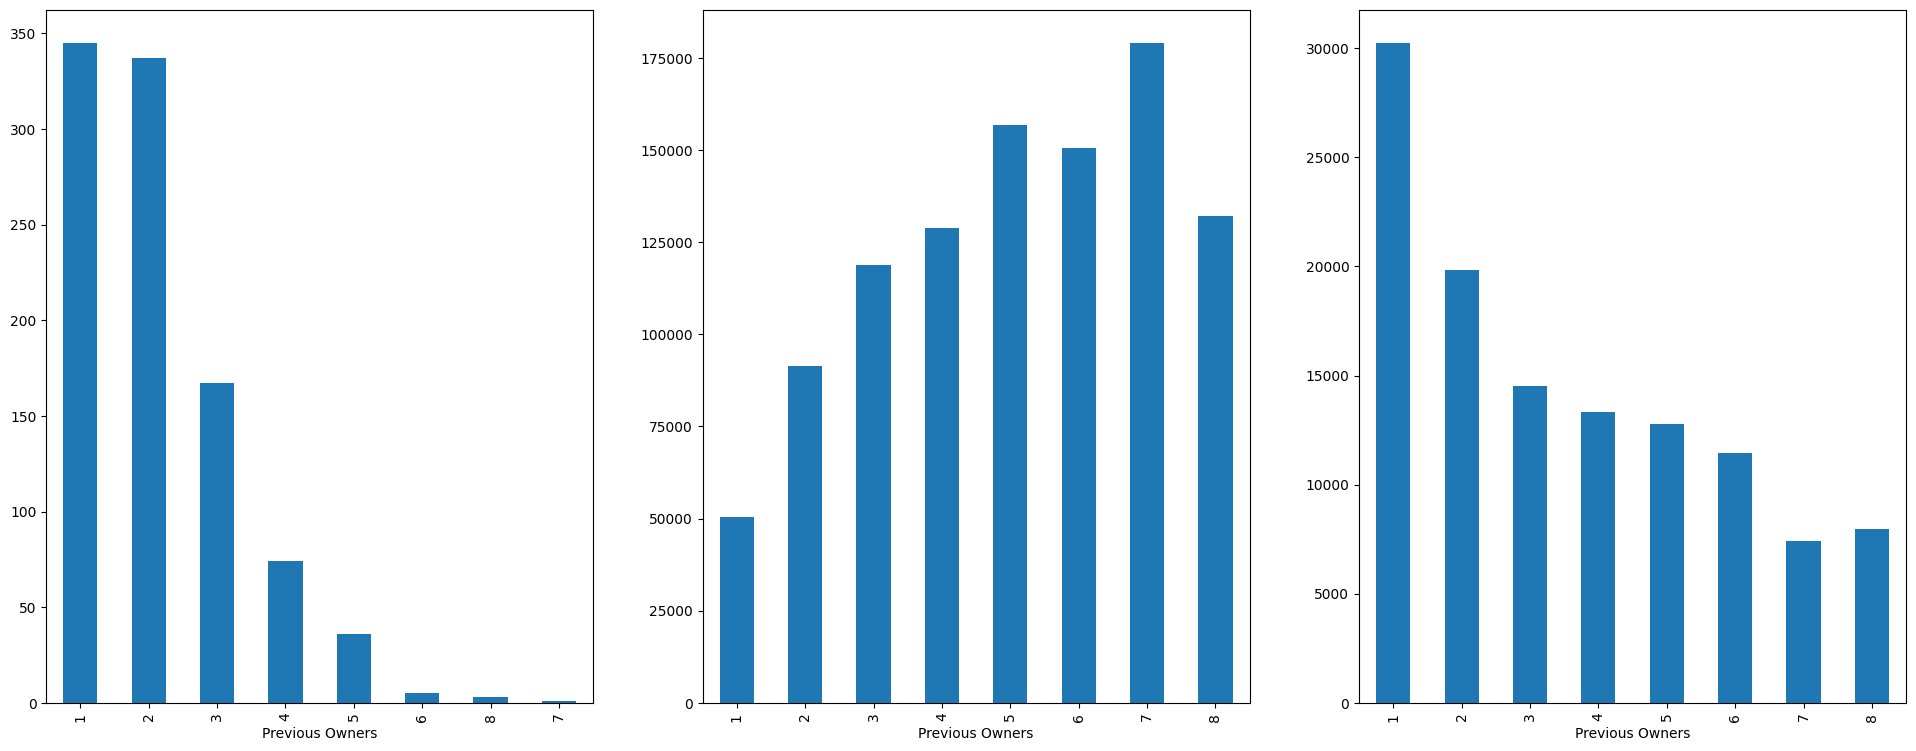

In [38]:
# Plots of Previous owners
# 1. Plots of previous owners vs Mileage, # 2. Previous owners vs Price, #3. Distribution of previous owners


fig, axes = plt.subplots(1, 3, figsize=(24, 9))

df["Previous Owners"].value_counts().plot(kind="bar", ax = axes[0]) 

df.groupby("Previous Owners")["Mileage"].mean().plot(ax=axes[1], kind ="bar")
df.groupby("Previous Owners")["Price"].mean().plot(ax=axes[2], kind ="bar")

<Axes: xlabel='Colour'>

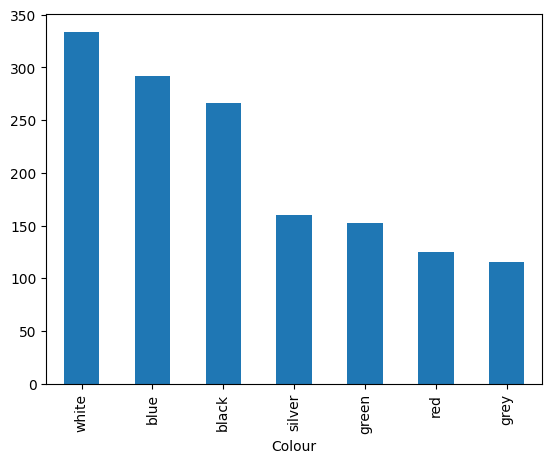

In [40]:
# Colour plots
# 1. Most popular Colours
df["Colour"].value_counts().plot(kind="bar")